In [75]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from sklearn.metrics import accuracy_score, confusion_matrix
from helper.algorithms import ClassificationAlgorithms

In [76]:

# Plot settings
plt.style.use("fivethirtyeight")
plt.rcParams["figure.figsize"] = (20, 5)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["lines.linewidth"] = 2

### Apply on 2 df_filter and no filter

In [77]:
df_filter = pd.read_pickle("../processed_data/data_Filter.pkl")
df_NoFilter = pd.read_pickle("../processed_data/data_NoFilter.pkl")

df_filter = df_filter.drop("epoch (ms)", axis=1)

#### Staring with df FILTER

In [78]:
df_train = df_filter.drop(["Participants", "Category", "Set"], axis=1)

X = df_train.drop("Label", axis=1)
y = df_train["Label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

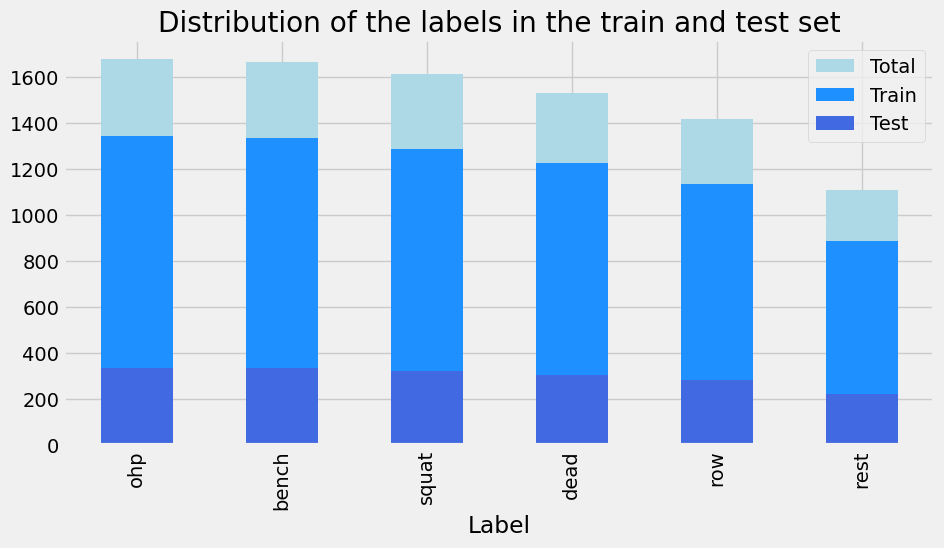

In [79]:
# create a plot
fig, ax = plt.subplots(figsize=(10, 5))
df_train["Label"].value_counts().plot(
    kind="bar", ax=ax, color = "lightblue", label="Total"
   )
y_train.value_counts().plot(kind="bar", ax=ax, color = "dodgerblue", label="Train")
y_test.value_counts().plot(kind="bar", ax=ax, color = "royalblue", label="Test")
plt.legend()
plt.title("Distribution of the labels in the train and test set")
plt.show()


In [80]:
df_filter.columns

Index(['Accelerometer_x', 'Accelerometer_y', 'Accelerometer_z', 'Gyroscope_x',
       'Gyroscope_y', 'Gyroscope_z', 'Participants', 'Label', 'Category',
       'Set', 'pca_1', 'pca_2', 'pca_3', 'Accelerometer_r', 'Gyroscope_r',
       'cluster_acc', 'cluster_gyro'],
      dtype='object')

In [81]:
# split the features 
basic_features = ["Accelerometer_x", "Accelerometer_y", "Accelerometer_z", "Gyroscope_x", "Gyroscope_y", "Gyroscope_z"]
squere_feactures = ["Accelerometer_r", "Gyroscope_r"]
pca_feactures = ["pca_1", "pca_2", "pca_3"]
cluster_feactures = ["cluster_acc", "cluster_gyro"]

print(f"Basic features: ", len(basic_features))
print(f"Squere features: ", len(squere_feactures))
print(f"PCA features: ", len(pca_feactures))
print(f"Cluster features: ", len(cluster_feactures))


Basic features:  6
Squere features:  2
PCA features:  3
Cluster features:  2


In [82]:
# creating the feature sets
feature_set_1 = list(set(basic_features))
feature_set_2 = list(set(feature_set_1 + squere_feactures))
feature_set_3 = list(set(feature_set_2 + pca_feactures))
feature_set_4 = list(set(feature_set_3 + cluster_feactures))

In [83]:
# preform forword selection using decision tree
X_train = X_train.select_dtypes(exclude=['datetime64[ns]'])

# select 10 best features
learner = ClassificationAlgorithms()

max_features = 10
selected_features, ordered_features, ordered_scores = learner.forward_selection(max_features, X_train, y_train)

0
1
2
3
4
5
6
7
8
9


Text(0.5, 1.0, 'Forward selection')

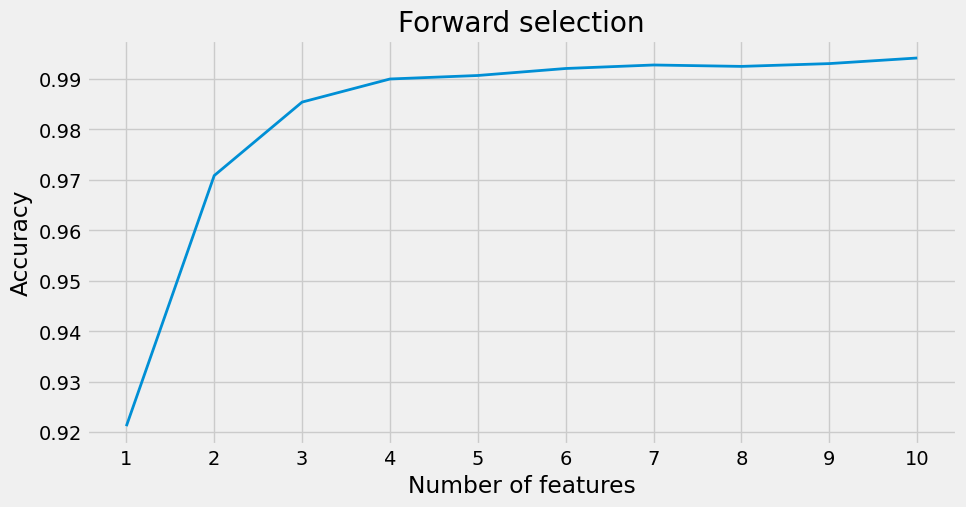

In [84]:
plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, max_features + 1, 1), ordered_scores)
plt.xlabel("Number of features")
plt.ylabel("Accuracy")
plt.xticks(np.arange(1, max_features + 1, 1))
plt.title("Forward selection")


In [85]:
possible_feature_sets = [feature_set_1, feature_set_2, feature_set_3, feature_set_4, selected_features]
feature_names = ["Feature set 1", "Feature set 2", "Feature set 3", "Feature set 4", "Selected features"]

iterations = 1

score_df = pd.DataFrame()


for i, f in zip(range(len(possible_feature_sets)), feature_names):
    print("Feature set:", i)
    selected_train_X = X_train[possible_feature_sets[i]]
    selected_test_X = X_test[possible_feature_sets[i]]

    # First run non-deterministic classifiers to average their score.
    performance_test_rf = 0

    for it in range(0, iterations):

        print("\tTraining random forest,", it)
        (
            class_train_y,
            class_test_y,
            class_train_prob_y,
            class_test_prob_y,
        ) = learner.random_forest(
            selected_train_X, y_train, selected_test_X, gridsearch=True
        )
        performance_test_rf += accuracy_score(y_test, class_test_y)

    performance_test_rf = performance_test_rf / iterations

    # Run the deterministic classifiers:
    
    # KNN
    print("\tTraining KNN")
    (
        class_train_y,
        class_test_y,
        class_train_prob_y,
        class_test_prob_y,
    ) = learner.k_nearest_neighbor(
        selected_train_X, y_train, selected_test_X, gridsearch=True
    )
    performance_test_knn = accuracy_score(y_test, class_test_y)

    # Decision Tree
    print("\tTraining decision tree")
    (
        class_train_y,
        class_test_y,
        class_train_prob_y,
        class_test_prob_y,
    ) = learner.decision_tree(
        selected_train_X, y_train, selected_test_X, gridsearch=True
    )
    performance_test_dt = accuracy_score(y_test, class_test_y)

    # Naive Bayes
    print("\tTraining naive bayes")
    (
        class_train_y,
        class_test_y,
        class_train_prob_y,
        class_test_prob_y,
    ) = learner.naive_bayes(selected_train_X, y_train, selected_test_X)

    performance_test_nb = accuracy_score(y_test, class_test_y)

    # SVM with kernel
    print("\tTraining SVM with kernel")
    (
        class_train_y,
        class_test_y,
        class_train_prob_y,
        class_test_prob_y,
    ) = learner.support_vector_machine_with_kernel(
        selected_train_X, y_train, selected_test_X, gridsearch=True
    )
    performance_test_svm_kernel = accuracy_score(y_test, class_test_y)

    # SVM without kernel (LinearSVC)
    print("\tTraining SVM without kernel")
    (
        class_train_y,
        class_test_y,
        class_train_prob_y,
        class_test_prob_y,
    ) = learner.support_vector_machine_without_kernel(
        selected_train_X, y_train, selected_test_X, gridsearch=True
    )
    performance_test_svm_no_kernel = accuracy_score(y_test, class_test_y)

    # Save results to dataframe
    models = ["RF", "KNN", "DT", "NB", "SVM-Kernel", "SVM-No-Kernel"]
    new_scores = pd.DataFrame(
        {
            "model": models,
            "feature_set": f,
            "accuracy": [
                performance_test_rf,
                performance_test_knn,
                performance_test_dt,
                performance_test_nb,
                performance_test_svm_kernel,
                performance_test_svm_no_kernel,
            ],
        }
    )
    score_df = pd.concat([score_df, new_scores])


Feature set: 0
	Training random forest, 0
	Training KNN
	Training decision tree
	Training naive bayes
	Training SVM with kernel
	Training SVM without kernel
Feature set: 1
	Training random forest, 0
	Training KNN
	Training decision tree
	Training naive bayes
	Training SVM with kernel
	Training SVM without kernel
Feature set: 2
	Training random forest, 0
	Training KNN
	Training decision tree
	Training naive bayes
	Training SVM with kernel
	Training SVM without kernel
Feature set: 3
	Training random forest, 0
	Training KNN
	Training decision tree
	Training naive bayes
	Training SVM with kernel
	Training SVM without kernel
Feature set: 4
	Training random forest, 0
	Training KNN
	Training decision tree
	Training naive bayes
	Training SVM with kernel
	Training SVM without kernel


In [88]:
score_df.sort_values(by="accuracy", ascending=False, inplace=True)
score_df

,model,feature_set,accuracy
0,RF,Feature set 2,0.961154
0,RF,Feature set 4,0.961154
0,RF,Feature set 3,0.960044
0,RF,Selected features,0.959489
0,RF,Feature set 1,0.957270
2,DT,Selected features,0.938402
2,DT,Feature set 4,0.937847
2,DT,Feature set 3,0.935627
2,DT,Feature set 2,0.925638
2,DT,Feature set 1,0.925083


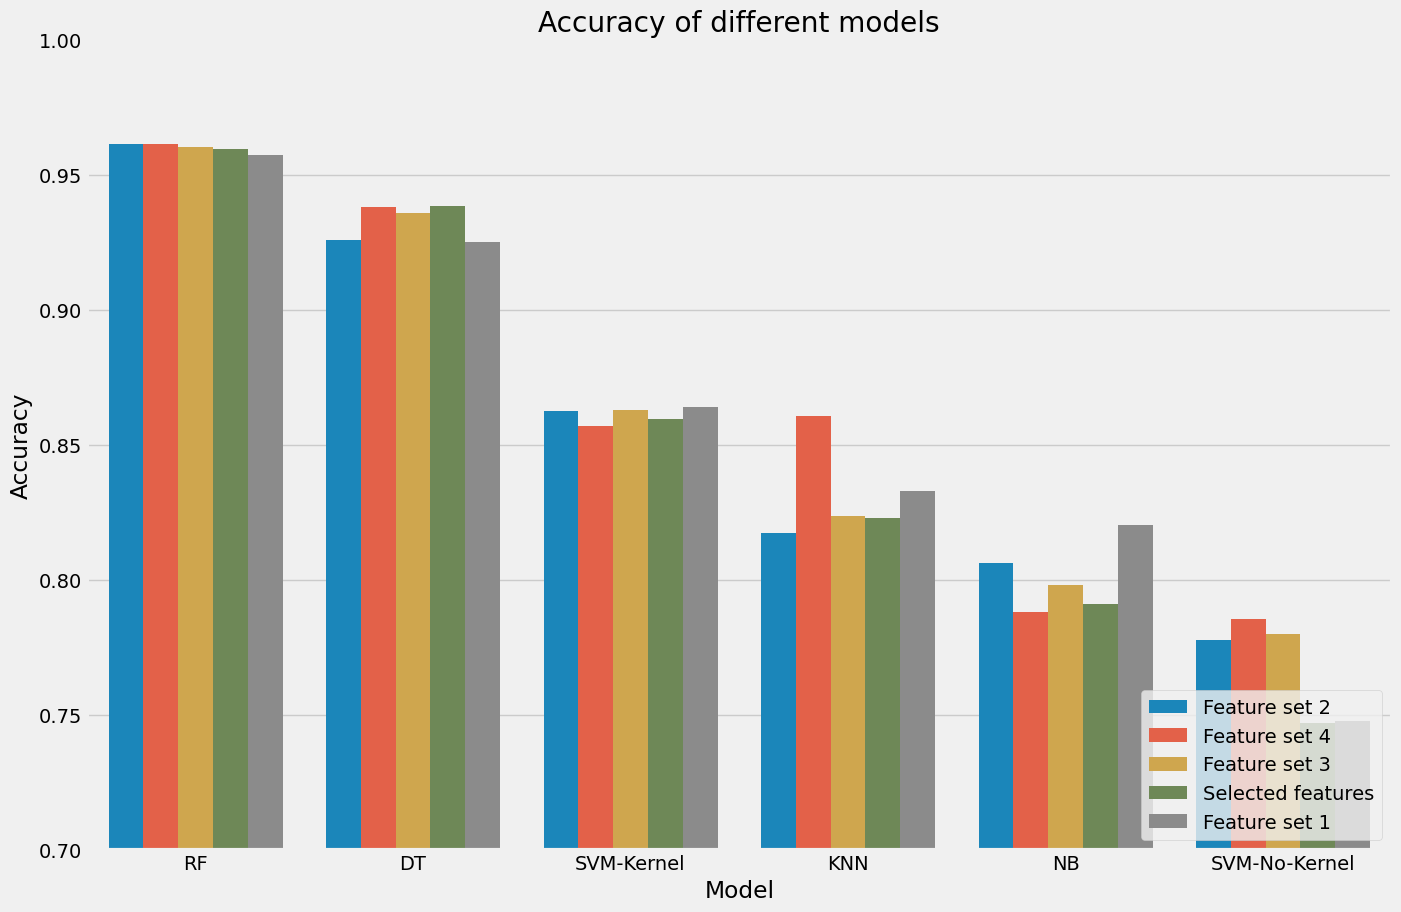

In [89]:
plt.figure(figsize=(15, 10))
sns.barplot(x="model", y="accuracy", hue="feature_set", data=score_df)
plt.title("Accuracy of different models")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0.7, 1)
plt.legend(loc="lower right")
plt.show()

In [90]:
# random forest
(
    class_train_y,
    class_test_y,
    class_train_prob_y,
    class_test_prob_y,
) = learner.random_forest(X_train[feature_set_4], y_train, X_test[feature_set_4], gridsearch=True)

In [91]:
# confusion matrix
classes = class_test_prob_y.columns
cm = confusion_matrix(y_test, class_test_y, labels=classes)
cm

array([[307,   0,  26,   0,   0,   0],
       [  0, 302,   0,   0,   4,   0],
       [ 24,   0, 309,   0,   0,   2],
       [  0,   0,   0, 222,   0,   0],
       [  0,  15,   0,   0, 269,   0],
       [  0,   0,   0,   0,   0, 322]])

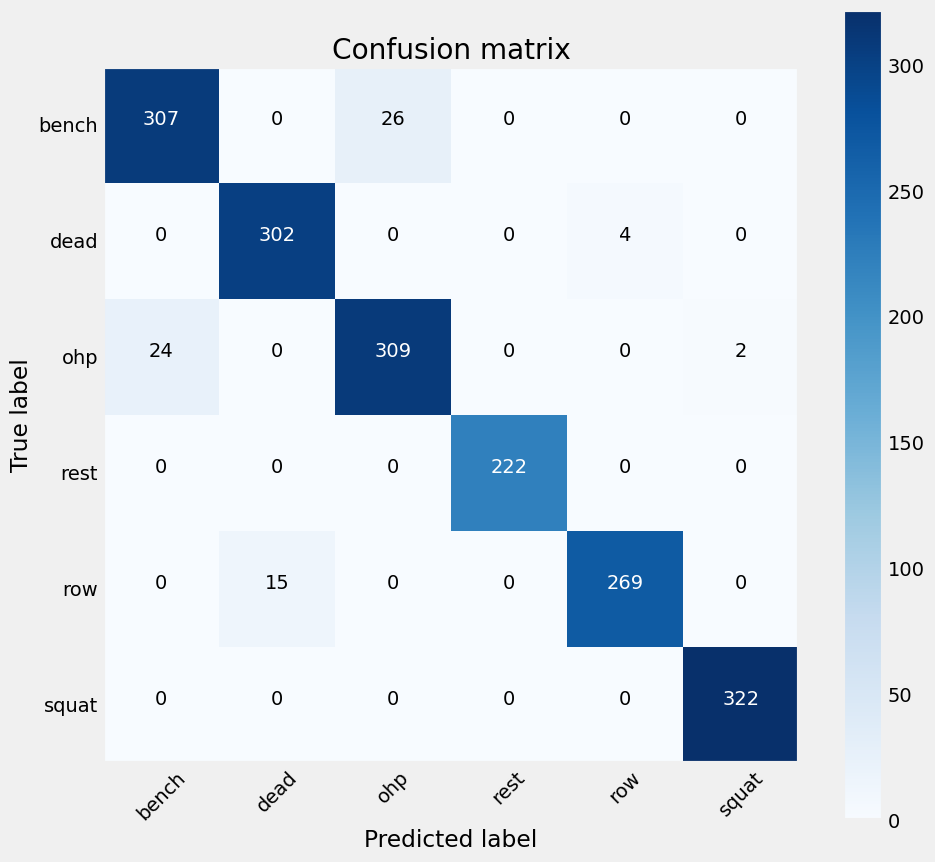

In [92]:
# create confusion matrix for cm
plt.figure(figsize=(10, 10))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion matrix")
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

thresh = cm.max() / 2.0
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(
        j,
        i,
        format(cm[i, j]),
        horizontalalignment="center",
        color="white" if cm[i, j] > thresh else "black",
    )
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.grid(False)
plt.show()

In [93]:
# print the accurency 
print("Accuracy: ", accuracy_score(y_test, class_test_y))

Accuracy:  0.9605993340732519


### No Filtered data

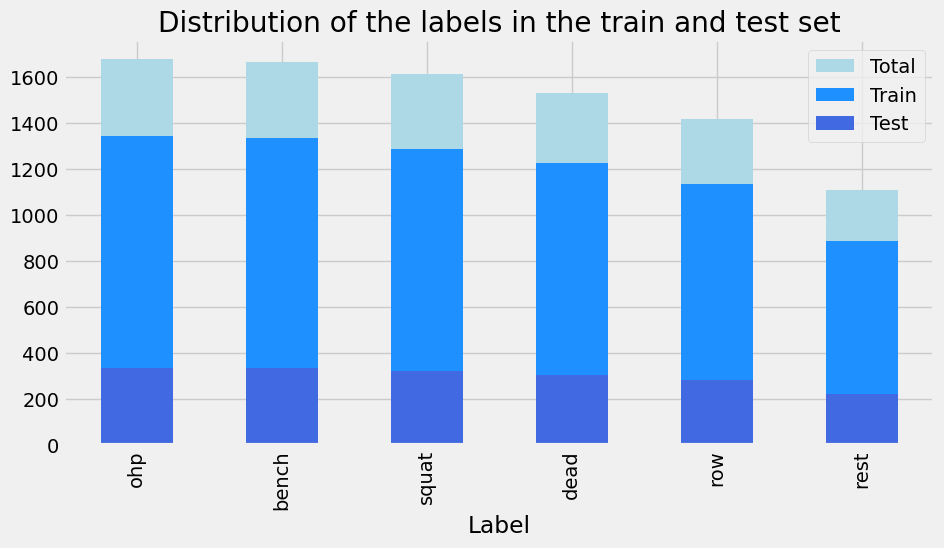

In [94]:
df_NoFilter = df_NoFilter.drop("epoch (ms)", axis=1)

df_train = df_NoFilter.drop(["Participants", "Category", "Set"], axis=1)

X = df_train.drop("Label", axis=1)
y = df_train["Label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# create a plot
fig, ax = plt.subplots(figsize=(10, 5))
df_train["Label"].value_counts().plot(
    kind="bar", ax=ax, color = "lightblue", label="Total"
   )
y_train.value_counts().plot(kind="bar", ax=ax, color = "dodgerblue", label="Train")
y_test.value_counts().plot(kind="bar", ax=ax, color = "royalblue", label="Test")
plt.legend()
plt.title("Distribution of the labels in the train and test set")
plt.show()

In [95]:
# split the features
basic_features = ["Accelerometer_x", "Accelerometer_y", "Accelerometer_z", "Gyroscope_x", "Gyroscope_y", "Gyroscope_z"]
squere_feactures = ["Accelerometer_r", "Gyroscope_r"]
pca_feactures = ["pca_1", "pca_2", "pca_3"]
cluster_feactures = ["cluster_acc", "cluster_gyro"]

print(f"Basic features: ", len(basic_features))
print(f"Squere features: ", len(squere_feactures))
print(f"PCA features: ", len(pca_feactures))
print(f"Cluster features: ", len(cluster_feactures))

Basic features:  6
Squere features:  2
PCA features:  3
Cluster features:  2


0
1
2
3
4
5
6
7
8
9


Text(0.5, 1.0, 'Forward selection')

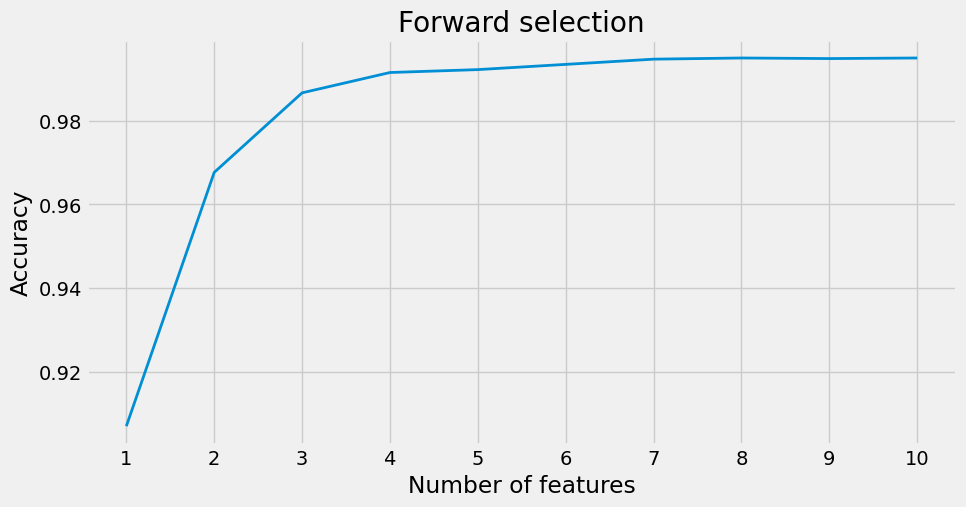

In [96]:
# creating the feature sets
feature_set_1 = list(set(basic_features))
feature_set_2 = list(set(feature_set_1 + squere_feactures))
feature_set_3 = list(set(feature_set_2 + pca_feactures))
feature_set_4 = list(set(feature_set_3 + cluster_feactures))

# preform forword selection using decision tree
X_train = X_train.select_dtypes(exclude=['datetime64[ns]'])

# select 10 best features
learner = ClassificationAlgorithms()

max_features = 10
selected_features, ordered_features, ordered_scores = learner.forward_selection(max_features, X_train, y_train)

plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, max_features + 1, 1), ordered_scores)
plt.xlabel("Number of features")
plt.ylabel("Accuracy")
plt.xticks(np.arange(1, max_features + 1, 1))
plt.title("Forward selection")

In [97]:

possible_feature_sets = [feature_set_1, feature_set_2, feature_set_3, feature_set_4, selected_features]
feature_names = ["Feature set 1", "Feature set 2", "Feature set 3", "Feature set 4", "Selected features"]

iterations = 1

score_df = pd.DataFrame()


for i, f in zip(range(len(possible_feature_sets)), feature_names):
    print("Feature set:", i)
    selected_train_X = X_train[possible_feature_sets[i]]
    selected_test_X = X_test[possible_feature_sets[i]]

    # First run non-deterministic classifiers to average their score.
    performance_test_rf = 0

    for it in range(0, iterations):

        print("\tTraining random forest,", it)
        (
            class_train_y,
            class_test_y,
            class_train_prob_y,
            class_test_prob_y,
        ) = learner.random_forest(
            selected_train_X, y_train, selected_test_X, gridsearch=True
        )
        performance_test_rf += accuracy_score(y_test, class_test_y)

    performance_test_rf = performance_test_rf / iterations

    # Run the deterministic classifiers:
    
    # KNN
    print("\tTraining KNN")
    (
        class_train_y,
        class_test_y,
        class_train_prob_y,
        class_test_prob_y,
    ) = learner.k_nearest_neighbor(
        selected_train_X, y_train, selected_test_X, gridsearch=True
    )
    performance_test_knn = accuracy_score(y_test, class_test_y)

    # Decision Tree
    print("\tTraining decision tree")
    (
        class_train_y,
        class_test_y,
        class_train_prob_y,
        class_test_prob_y,
    ) = learner.decision_tree(
        selected_train_X, y_train, selected_test_X, gridsearch=True
    )
    performance_test_dt = accuracy_score(y_test, class_test_y)

    # Naive Bayes
    print("\tTraining naive bayes")
    (
        class_train_y,
        class_test_y,
        class_train_prob_y,
        class_test_prob_y,
    ) = learner.naive_bayes(selected_train_X, y_train, selected_test_X)

    performance_test_nb = accuracy_score(y_test, class_test_y)

    # SVM with kernel
    #print("\tTraining SVM with kernel")
    #(
    #    class_train_y,
    #    class_test_y,
    #    class_train_prob_y,
    #    class_test_prob_y,
    #) = learner.support_vector_machine_with_kernel(
     #   selected_train_X, y_train, selected_test_X, gridsearch=True
    #)
   # performance_test_svm_kernel = accuracy_score(y_test, class_test_y)

    # SVM without kernel (LinearSVC)
    print("\tTraining SVM without kernel")
    (
        class_train_y,
        class_test_y,
        class_train_prob_y,
        class_test_prob_y,
    ) = learner.support_vector_machine_without_kernel(
        selected_train_X, y_train, selected_test_X, gridsearch=True
    )
    performance_test_svm_no_kernel = accuracy_score(y_test, class_test_y)

    # Save results to dataframe
    models = ["RF", "KNN", "DT", "NB", "SVM-No-Kernel"]
    new_scores = pd.DataFrame(
        {
            "model": models,
            "feature_set": f,
            "accuracy": [
                performance_test_rf,
                performance_test_knn,
                performance_test_dt,
                performance_test_nb,
                performance_test_svm_no_kernel,
            ],
        }
    )
    score_df = pd.concat([score_df, new_scores])


Feature set: 0
	Training random forest, 0
	Training KNN
	Training decision tree
	Training naive bayes
	Training SVM without kernel
Feature set: 1
	Training random forest, 0
	Training KNN
	Training decision tree
	Training naive bayes
	Training SVM without kernel
Feature set: 2
	Training random forest, 0
	Training KNN
	Training decision tree
	Training naive bayes
	Training SVM without kernel
Feature set: 3
	Training random forest, 0
	Training KNN
	Training decision tree
	Training naive bayes
	Training SVM without kernel
Feature set: 4
	Training random forest, 0
	Training KNN
	Training decision tree
	Training naive bayes
	Training SVM without kernel


In [98]:
score_df.sort_values(by="accuracy", ascending=False, inplace=True)
score_df

,model,feature_set,accuracy
0,RF,Feature set 2,0.976693
0,RF,Feature set 1,0.975583
0,RF,Feature set 3,0.975028
0,RF,Feature set 4,0.975028
0,RF,Selected features,0.973363
2,DT,Feature set 4,0.953940
2,DT,Selected features,0.951720
2,DT,Feature set 3,0.948391
2,DT,Feature set 2,0.946171
2,DT,Feature set 1,0.945061


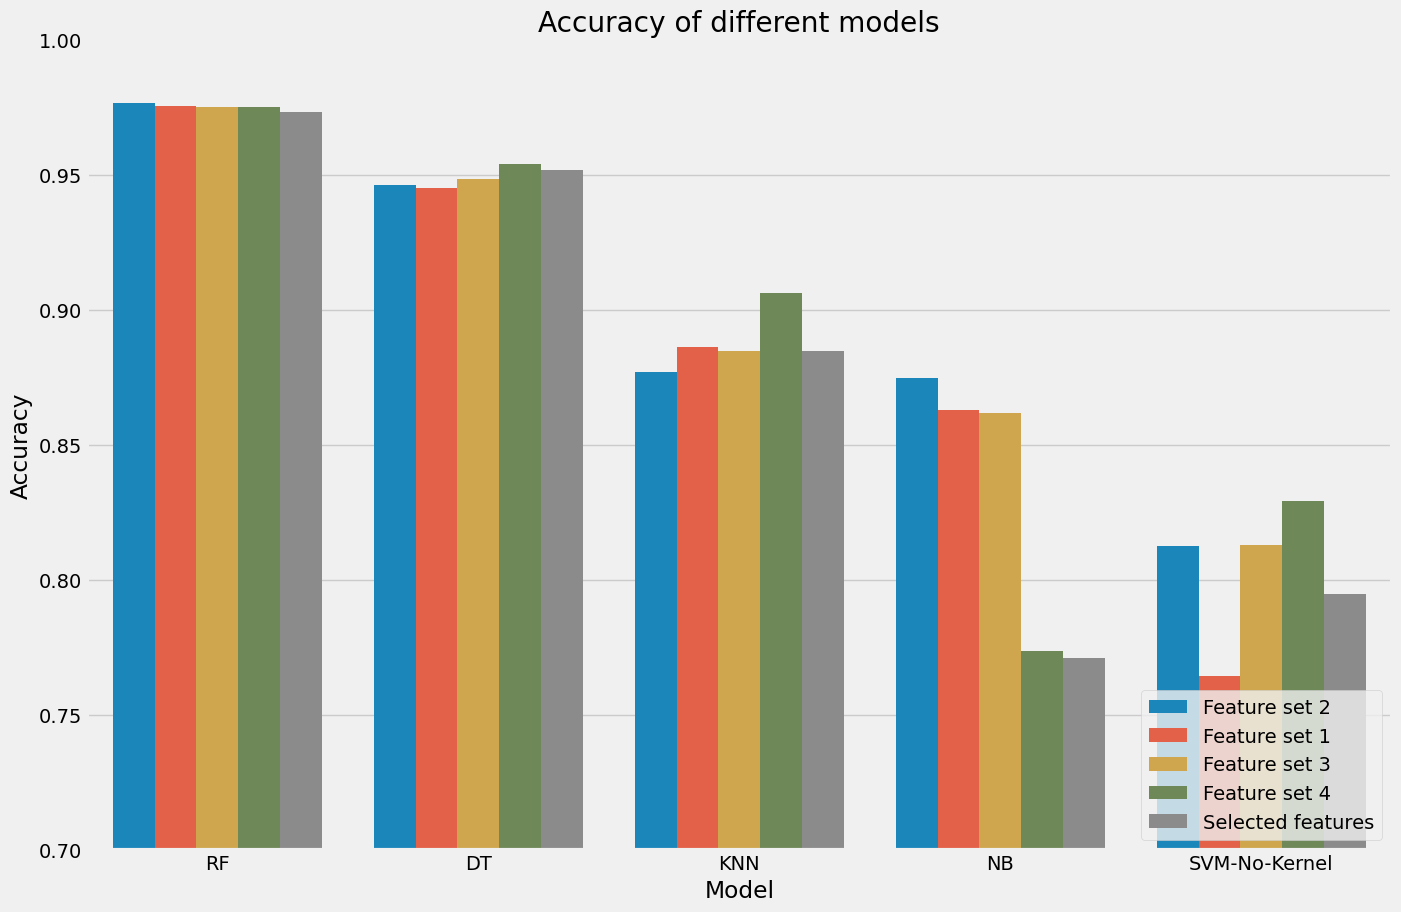

In [99]:
# plot the results
plt.figure(figsize=(15, 10))
sns.barplot(x="model", y="accuracy", hue="feature_set", data=score_df)
plt.title("Accuracy of different models")
plt.xlabel("Model")

plt.ylabel("Accuracy")
plt.ylim(0.7, 1)
plt.legend(loc="lower right")
plt.show()

In [100]:
# random forest
(
    class_train_y,
    class_test_y,
    class_train_prob_y,
    class_test_prob_y,
) = learner.random_forest(X_train[feature_set_4], y_train, X_test[feature_set_4], gridsearch=True)

In [101]:
# confusion matrix

classes = class_test_prob_y.columns
cm = confusion_matrix(y_test, class_test_y, labels=classes)
cm

array([[314,   0,  19,   0,   0,   0],
       [  0, 303,   0,   0,   3,   0],
       [ 11,   0, 324,   0,   0,   0],
       [  0,   0,   0, 222,   0,   0],
       [  0,   9,   0,   0, 275,   0],
       [  0,   0,   0,   0,   0, 322]])

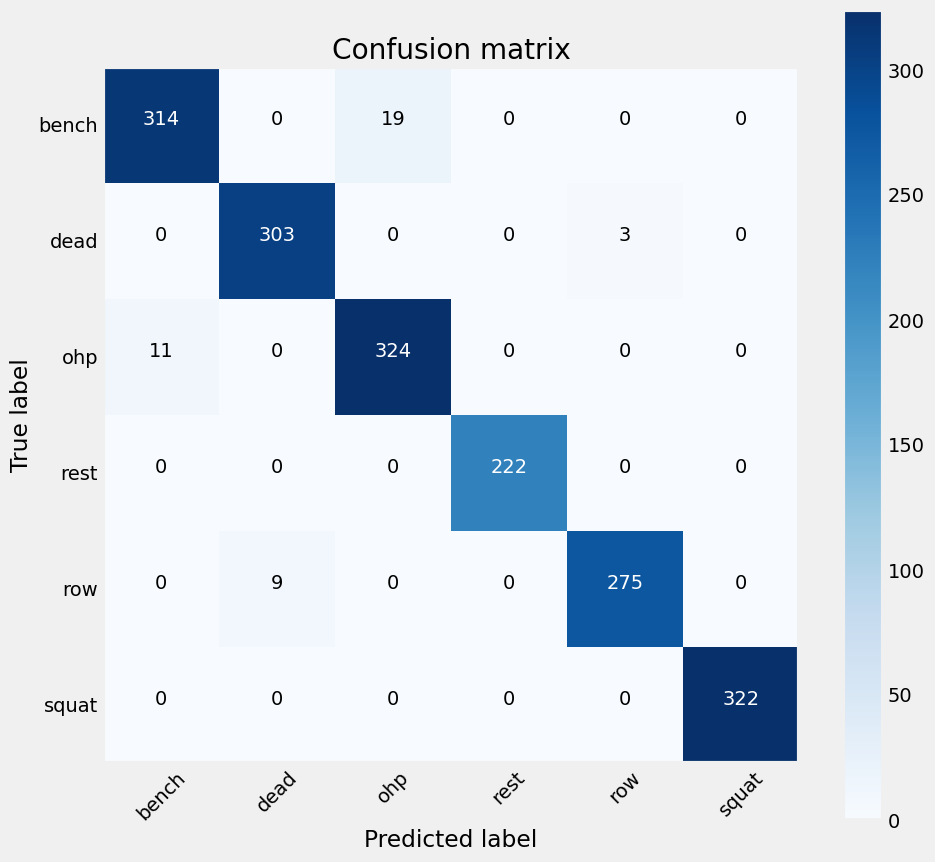

In [102]:
# create confusion matrix for cm
plt.figure(figsize=(10, 10))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion matrix")
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

thresh = cm.max() / 2.0

for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(
        j,
        i,
        format(cm[i, j]),
        horizontalalignment="center",
        color="white" if cm[i, j] > thresh else "black",
    )
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.grid(False)
plt.show()